In [1]:
#Basics in order to process the data and plot it

import numpy as np
import pandas as pd
import tkinter as tk
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
from datetime import datetime
import os 
import sys
import re
import signal
import openpyxl
import glob
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates


def serial_ports():
    """ Lists serial port names

        :raises EnvironmentError:
            On unsupported or unknown platforms
        :returns:
            A list of the serial ports available on the system
    """
    if sys.platform.startswith('win'):
        ports = ['COM%s' % (i + 1) for i in range(256)]
    elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
        # this excludes your current terminal "/dev/tty"
        ports = glob.glob('/dev/tty[A-Za-z]*')
    elif sys.platform.startswith('darwin'):
        ports = glob.glob('/dev/tty.*')
    else:
        raise EnvironmentError('Unsupported platform')

    result = []
    for port in ports:
        try:
            s = serial.Serial(port)
            s.close()
            result.append(port)
        except (OSError, serial.SerialException):
            pass
    return result

def findDevice(question="hello", answer="", flush=False, timeout=5):
    for port in serial_ports():
        with serial.Serial(port, baudrate=115200, timeout=timeout) as ser:
            time.sleep(2)  # let the board finish resetting after port open
            ser.reset_input_buffer()

            if flush:
                ser.flush()
                time.sleep(0.5)

            ser.write(question.encode())
            time.sleep(0.5)

            msg = ser.readline().decode(errors="replace")
            print(f"{port}: {msg!r}")
            if answer and answer in msg:
                print(f"Found device at: {port}, answer: {msg}")
                return port
    return None

def send_read_command(port, string, required_string=None, baudrate=115200, timeout=10):
    """
    Opens the serial port, sends a “hello” and then your command, and collects replies.
    Stops reading when either:
      • no more data arrives (an empty readline, i.e. per-read timeout fired), or
      • we see `required_string` in the response, if given, or
      • the overall `timeout` has elapsed.
    Returns the list of lines read so far.
    """
    lines = []
    start = time.monotonic()
    with serial.Serial(port, baudrate=baudrate, timeout=timeout) as ser:
        # hand-shake / mode set
        ser.setRTS(False)
        ser.flush()
        time.sleep(0.7)
        ser.write(b"hello\n")
        time.sleep(0.5)
        ser.write(f"{string}\n".encode())
        last_recv = time.monotonic()

        while True:
            # Check idle timeout
            now = time.monotonic()
            if now - last_recv >= timeout:
                print(f"No (additional) responses within user-set timeout: {timeout}s")
                return lines
            
            try:
                line = ser.readline().decode('utf-8', errors='replace').strip()
                # print(line)
                
                last_recv = time.monotonic() # Reset idle timer since we got data
            except Exception as e:
                print(f"Error reading line: {e!s}")
                break

            # if nothing arrived within per-read timeout, readline() returns b'' → line == ''
            if not line:
                print(f"No (additional) responses within user-set timeout: {timeout}s")
                return lines
                
            lines.append(line)

            # if we were waiting for a specific marker, stop when we see it
            if required_string and required_string in line:
                break
    return lines

In [2]:
PORT = findDevice(question="hello\r\n", answer="C12666MA,v1.0", timeout=5)
if not PORT:
    raise RuntimeError("Device not found on any port")# Replace with the appropriate serial port for your device      

ser = serial.Serial(PORT, baudrate=115200, timeout=5)
time.sleep(2)  # Wait for the serial connection to initialize
ser.reset_input_buffer()

ser.write(b"hello\n")
message = ser.readline()
print(message.decode().strip())
time.sleep(1)
ser.close()

COM15: 'C12666MA,v1.0\r\r\n'
Found device at: COM15, answer: C12666MA,v1.0

C12666MA,v1.0


In [3]:
#functions to set and get gain, integration time, and averaging count. cuttently not used in the notebook, but can be used to set the parameters of the device.
def set_gain(gain, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_gain,{gain}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_integration(integration_time, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_integration,{integration_time}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_avg(average_count, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_avg,{average_count}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def get_avg(port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"get_avg\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def get_integration(port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"get_integration\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_led(led_state, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_led,{led_state}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()
    

In [4]:
def set_config(port=PORT, avg=15, integration_time=100000, gain=1, led=0):
    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(0.3)
        ser.reset_input_buffer()

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()

        send_command(f"set_gain,{gain}")
        send_command(f"set_integration,{integration_time}")
        send_command(f"set_avg,{avg}")
        send_command(f"set_led,{led}")

    return None

dark_spectrum = None

def dark(port=PORT):
    global dark_spectrum

    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(2)
        ser.reset_input_buffer()

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()

        send_command("set_gain,1")
        send_command("set_integration,100000")
        send_command("set_avg,10")
        send_command("set_led,0")

        ser.write(b"spec,raw\n")
        specdark = ser.readline()
        dark_spectrum = specdark.decode(errors="replace").strip()

    return dark_spectrum


dark()   # measure and store dark spectrum

def get_raw_spec(port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(0.5)
        ser.reset_input_buffer()

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()


        ser.write(b"spec,raw\n")
        spec_raw1 = ser.readline()
        spec_light1 = spec_raw1.decode(errors="replace").strip()

        # send_command(f"set_led,0")

    spec_light = np.array(spec_light1.split(","), dtype=int)

    if dark_spectrum is None:
        raise ValueError("No dark spectrum has been measured. Call dark() first.")

    spec_dark = np.array(dark_spectrum.split(","), dtype=int)

    spec = np.maximum(spec_light - spec_dark, 0)

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    spec_str = ",".join(spec.astype(str))

    result = f"{timestamp},{spec_str}"

    return result

Measuring dark spectrum, iteration 1/5
Measuring dark spectrum, iteration 2/5
Measuring dark spectrum, iteration 3/5
Measuring dark spectrum, iteration 4/5
Measuring dark spectrum, iteration 5/5


C:\Users\tolsm012\AppData\Local\Temp\ipykernel_19588\2407310542.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


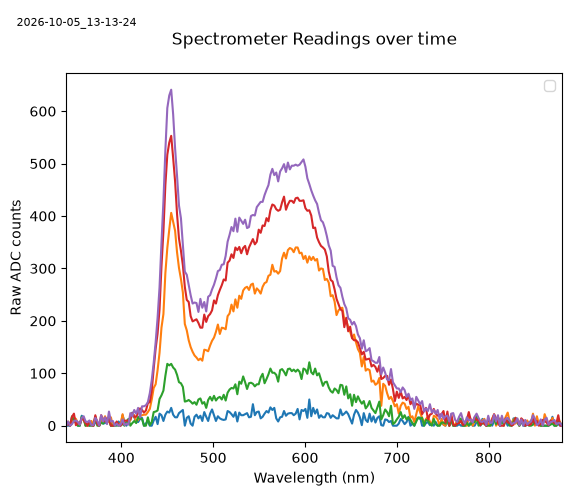

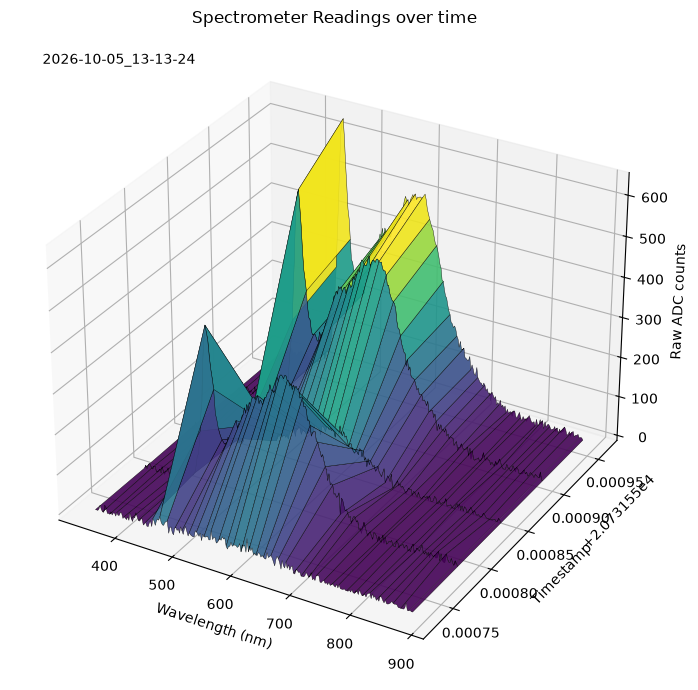

In [5]:
# Specify configs as [average count, integration time (us), gain, LED state].
config_dark = [15, 100000, 1, 0]
config_light = [15, 100000, 1, 1]

# Add or reorder measurement blocks here: (label, config, number of measurements).
measurement_sequence = [
    ("dark", config_dark, 5),
#     ("light", config_light, 3),
#     ("dark", config_dark, 5),
# #     ("light", config_light, 1),
#     ("dark", config_dark, 1),
#     ("light", config_light, 1),
#     ("dark", config_dark, 1),
#     ("light", config_light, 1),
#     ("dark", config_dark, 1),
    ]

# measurement_sequence = [
#      ("dark", config_dark, 50),
# ]

results = []
DELAY = 1

for measurement_type, config, measurement_count in measurement_sequence:
    set_config(PORT, *config)
    for measurement_index in range(measurement_count):
        print(
            f"Measuring {measurement_type} spectrum, "
            f"iteration {measurement_index + 1}/{measurement_count}"
        )
        read = get_raw_spec(PORT)
        timestamp, *spectrum_values = read.split(",")
        line = [timestamp] + [int(value) for value in spectrum_values]
        results.append(line)
        # y = [int(value) for value in spectrum_values]
        # plt.plot(np.linspace(340, 880, len(spectrum_values)), y)
        # plt.xlim(500, 880)
        # plt.ylim(0, 400)
        # plt.show()
        time.sleep(DELAY)

set_config(PORT, *config_dark)

n_pixels = 256
columns = ["timestamp"] + [f"pixel{i}" for i in range(n_pixels)]

data = pd.DataFrame(results, columns=columns)

now_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
safe_timestamp = now_timestamp.replace(":", "-").replace(" ", "_")
data.to_csv(os.path.join("data", f"spec {safe_timestamp}_data.csv"), index=False)
pixel_cols = [c for c in data.columns if c.startswith("pixel")]

x = np.linspace(340, 880, len(pixel_cols))

for i in range(len(data)):
    y = data.loc[i, pixel_cols]
    ynorm = y / np.max(y)  # Normalize the spectrum to its maximum value
    # label = f"gain={gain}, int_time={int_time}us, avg={avg}"
    plt.plot(x, y)

plt.legend()
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
# plt.ylim(0, 100)  # we have a signed 13-bit ADC. Voltage will not be negative, so functionally 12 bits
plt.xlim(340, 880)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Raw ADC counts")
plt.title("\n" + "Spectrometer Readings over time\n")
plt.show()

spectra = data[pixel_cols].to_numpy(dtype=float)

timestamps = pd.to_datetime(data["timestamp"])
time_num = mdates.date2num(timestamps)

X = np.tile(x, (len(data), 1))
Z = spectra
Y = np.tile(time_num[:, None], (1, len(pixel_cols)))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, alpha=0.9, linewidth=0.3, edgecolor="black", cmap="viridis")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Timestamp")
ax.set_zlabel("Raw ADC counts")
ax.set_title("Spectrometer Readings over time")

plt.tight_layout()
ax.text2D(0.05, 0.95, f"{safe_timestamp}", transform=ax.transAxes)
plt.show()

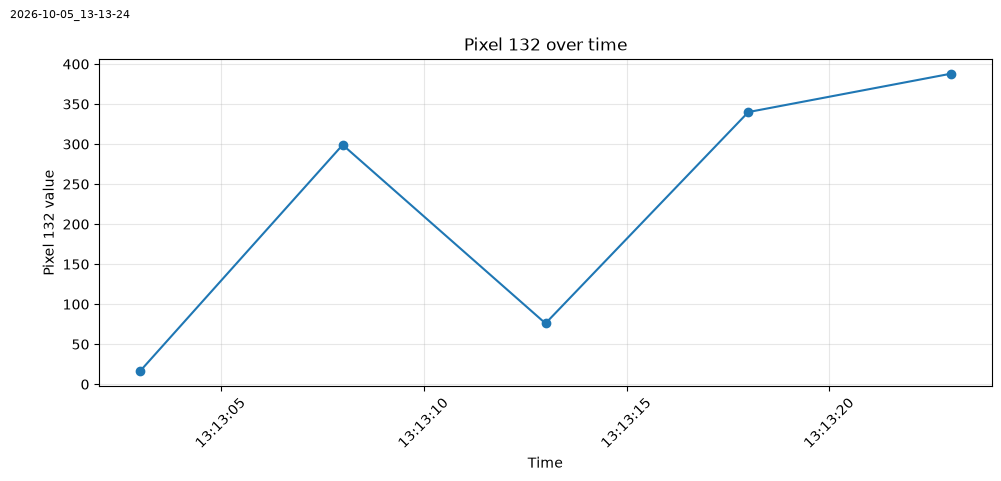

In [6]:
timestamps = pd.to_datetime(data["timestamp"])
pixel_132 = pd.to_numeric(data["pixel132"])

plt.figure(figsize=(10, 5))
plt.plot(timestamps, pixel_132, marker="o", linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Pixel 132 value")
plt.title("Pixel 132 over time")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

In [7]:
dark()

'332,348,330,333,333,333,325,330,322,330,339,329,328,334,330,331,336,335,341,330,329,344,339,329,345,330,321,337,334,339,338,333,337,338,338,349,338,352,357,370,384,402,419,455,479,525,598,675,790,953,1138,1326,1481,1578,1599,1533,1387,1258,1131,1045,967,906,838,815,783,755,745,734,748,742,747,750,770,783,801,813,832,841,851,859,879,903,918,948,977,1007,1046,1072,1081,1106,1111,1109,1103,1104,1113,1140,1136,1173,1174,1197,1199,1195,1213,1226,1248,1249,1264,1286,1308,1318,1322,1333,1323,1308,1299,1287,1286,1294,1302,1316,1341,1338,1341,1332,1315,1281,1256,1209,1203,1161,1142,1127,1095,1083,1068,1038,1026,989,945,912,871,843,805,778,768,737,721,722,716,717,696,717,697,682,685,661,643,627,626,610,577,583,572,561,547,546,543,517,503,498,476,481,459,464,449,451,446,447,444,444,430,424,415,410,404,398,388,403,403,384,383,386,376,380,380,374,364,363,366,370,361,358,356,355,375,369,350,352,353,373,343,350,361,347,348,349,340,344,337,362,337,347,335,331,344,334,339,333,339,342,344,345,345,339,3

In [14]:
get_raw_spec(PORT)

'2026-09-14 11:21:00,790,768,792,798,807,806,846,895,936,1017,1138,1227,1375,1505,1644,1725,1810,1903,2015,2176,2247,2298,2339,2323,2339,2334,2333,2348,2371,2405,2452,2505,2538,2615,2654,2690,2703,2698,2705,2695,2700,2719,2715,2705,2698,2724,2709,2719,2707,2708,2708,2697,2714,2729,2721,2724,2721,2726,2711,2704,2724,2719,2712,2711,2711,2714,2701,2714,2701,2722,2714,2722,2715,2726,2702,2728,2729,2712,2724,2726,2721,2732,2731,2722,2720,2720,2707,2723,2715,2728,2705,2727,2734,2741,2737,2733,2722,2726,2718,2736,2731,2722,2742,2737,2743,2730,2717,2744,2718,2732,2738,2727,2728,2735,2737,2735,2724,2743,2718,2752,2744,2745,2735,2732,2741,2734,2748,2731,2727,2735,2725,2724,2724,2733,2712,2724,2731,2716,2735,2725,2730,2731,2723,2725,2734,2736,2735,2719,2744,2714,2730,2724,2735,2741,2726,2738,2715,2730,2721,2734,2720,2729,2718,2731,2722,2734,2728,2722,2727,2721,2731,2731,2733,2730,2730,2732,2716,2711,2722,2728,2716,2732,2715,2717,2709,2713,2717,2727,2705,2715,2704,2721,2691,2662,2657,2601,2594,258

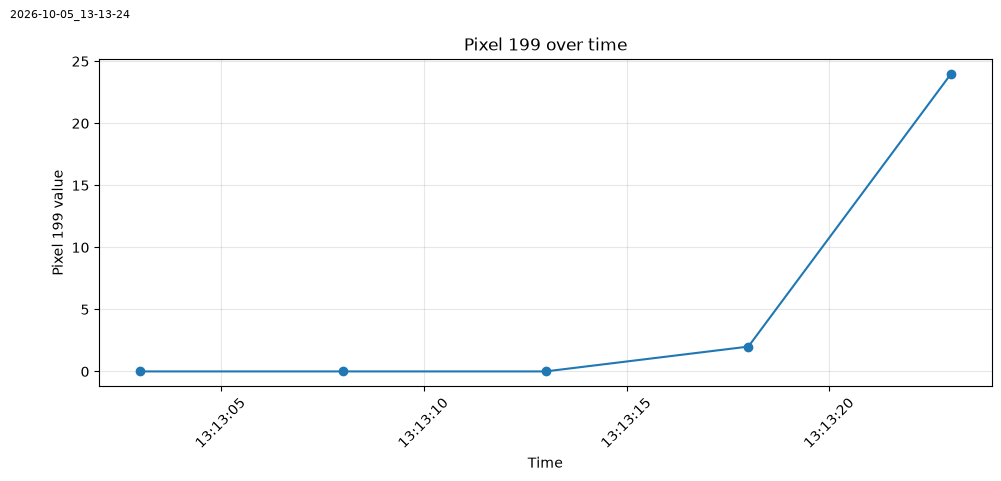

In [8]:
timestamps = pd.to_datetime(data["timestamp"])
pixel_199 = pd.to_numeric(data["pixel199"])

plt.figure(figsize=(10, 5))
plt.plot(timestamps, pixel_199, marker="o", linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Pixel 199 value")
plt.title("Pixel 199 over time")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()

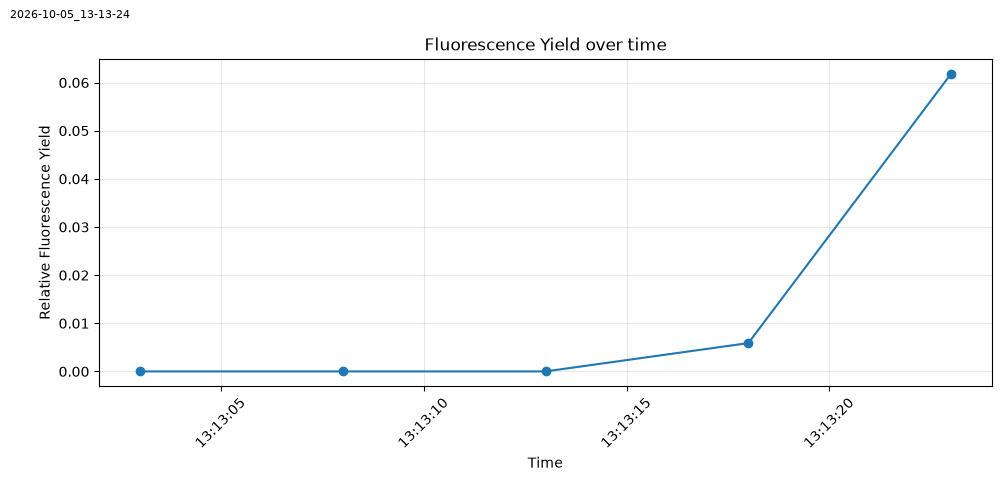

In [12]:
fyield_rel = pixel_199/pixel_132
fyield_rel = fyield_rel.fillna(0)  # Replace NaN values with 0
fyield_rel

plt.figure(figsize=(10, 5))
plt.plot(timestamps, fyield_rel, marker="o", linewidth=1.5)
plt.xlabel("Time")
plt.ylabel("Relative Fluorescence Yield")
plt.title("Fluorescence Yield over time")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.tight_layout()
plt.show()